<a href="https://colab.research.google.com/github/Yanina2105/MD-Lab10_FT/blob/develop/SEMANA_10_AN%C3%81LISIS_DE_CONGLOMERADOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SEMANA 10: ANÁLISIS DE CONGLOMERADOS**

1. Con base de la información de la base de datos ‘vehículos’ la cual contiene información sobre
diferentes modelos con las características más importantes que los definen, haga lo siguiente:

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('vehículos.csv')
df

,fabricante,modelo,year,desplazamiento,cilindros,transmision,traccion,clase,combustible,consumo,co2,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo,consumo_litros_milla
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,17,522.764706,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.222671
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,16,555.437500,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.236588
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,16,555.437500,Coches Medianos,dos,Automatica,Premium,grande,alto,alto,0.236588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36786,smart,fortwo coupe,2015,1.0,3.0,Automatic (AM5),Rear-Wheel Drive,Two Seaters,Premium,36,244.000000,Coches pequeños,dos,Automatica,Premium,muy pequeño,muy bajo,muy bajo,0.105150
36787,smart,fortwo coupe,2016,0.9,3.0,Automatic (AM6),Rear-Wheel Drive,Two Seaters,Premium,35,246.000000,Coches pequeños,dos,Automatica,Premium,muy pequeño,muy bajo,muy bajo,0.108155
36788,smart,fortwo coupe,2016,0.9,3.0,Manual 5-spd,Rear-Wheel Drive,Two Seaters,Premium,34,255.000000,Coches pequeños,dos,Manual,Premium,muy pequeño,muy bajo,muy bajo,0.111336
36789,smart,fortwo coupe,2017,0.9,3.0,Automatic (AM6),Rear-Wheel Drive,Two Seaters,Premium,35,248.000000,Coches pequeños,dos,Automatica,Premium,muy pequeño,muy bajo,muy bajo,0.108155


## **a. Realice el preprocesamiento de la información que incluya el análisis de datos faltantes, tratamiento de outliers a nivel univariado y multivariado, escalamiento de datos para las variables numéricas y dumización para las variables categóricas. Además, elimine las variables ‘fabricante’, ‘modelo’, ‘transmision’, ‘traccion’, ‘clase’, ‘combustible’ y ‘consumo’.**

In [12]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [15]:
# Eliminar columnas solicitadas
drop_cols = ['fabricante', 'modelo', 'transmision', 'traccion', 'clase', 'combustible', 'consumo']
df_clean = df.drop(columns=drop_cols)

In [16]:
# Codificar la variable 'clase_tipo' para evaluación externa
from sklearn.preprocessing import LabelEncoder
df_clean['clase_tipo_encoded'] = LabelEncoder().fit_transform(df_clean['clase_tipo'])

In [17]:
# Separar X (variables explicativas) y y (target externa)
X = df_clean.drop(columns=['clase_tipo', 'clase_tipo_encoded'])
y_external = df_clean['clase_tipo_encoded']

In [18]:
# Identificar columnas numéricas y categóricas
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [19]:
# Crear transformadores
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first'))
])

In [20]:
# ColumnTransformer para aplicar los preprocesamientos
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Aplicar el preprocesamiento
X_preprocessed = preprocessor.fit_transform(X)

## **b. Aplique un análisis de conglomerados no jerárquico por medio del método k-means y utilice el método del codo para determinar la cantidad de clusters adecuados. Compare los conglomerados formados y comente sobre las características que definen a estos.**

In [21]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [22]:
inertia = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_preprocessed)
    inertia.append(kmeans.inertia_)

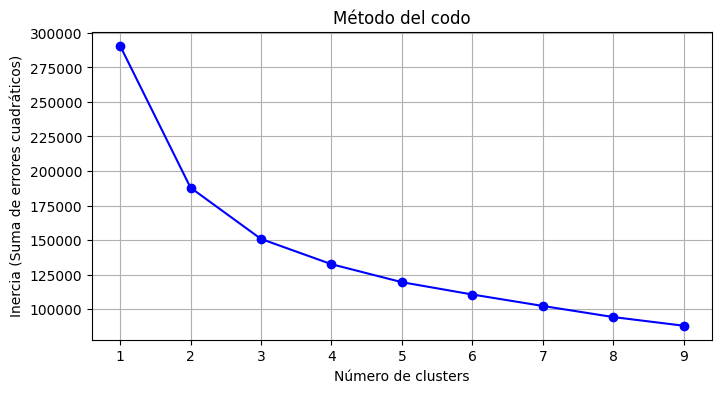

In [23]:
# Graficar método del codo
plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia (Suma de errores cuadráticos)')
plt.title('Método del codo')
plt.grid(True)
plt.show()

## **c. Calcule las principales medidas de evaluación interna e interprete los resultados obtenidos. También, calcule las principales medidas de evaluación externa tomando una cantidad de clusters de 8 y de referencia a la variable ‘clase_tipo’.**

In [26]:
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score, v_measure_score
from sklearn.cluster import KMeans

In [27]:
# KMeans con 8 clusters (para evaluación externa)
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_preprocessed)

In [28]:
# Evaluación interna
silhouette = silhouette_score(X_preprocessed, clusters)
print("Silhouette Score (interno):", silhouette)

Silhouette Score (interno): 0.24261163877728278


In [29]:
# Evaluación externa
homogeneity = homogeneity_score(y_external, clusters)
completeness = completeness_score(y_external, clusters)
v_measure = v_measure_score(y_external, clusters)

print("Homogeneidad (externo):", homogeneity)
print("Completitud (externo):", completeness)
print("V-measure (externo):", v_measure)

Homogeneidad (externo): 0.1384732192054688
Completitud (externo): 0.12456068119624487
V-measure (externo): 0.13114901528151282
